In [54]:
import torch.nn as nn
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [55]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
torch.mps.is_available()

True

In [56]:
#Definir la transformacion
transform = transforms.ToTensor()

#Descargar y cargar los Datasets
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False,
    download=True, 
    transform=transform
)

# Crear los DataLoaders (para manejar los datos en lotes)
# Usamos un tamaño de lote (batch_size) estándar de 64
train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=64, 
    shuffle=False
)

# Confirmacion de la carga
print("--- CIFAR-10 Cargado con Éxito ---")
print(f"Lotes de entrenamiento: {len(train_loader)} (Total de imágenes: {len(train_dataset)})")
print(f"Lotes de prueba: {len(test_loader)} (Total de imágenes: {len(test_dataset)})")

/Users/pl/Documents/VSCODE/InteligenciaComputacionalSem2/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


--- CIFAR-10 Cargado con Éxito ---
Lotes de entrenamiento: 782 (Total de imágenes: 50000)
Lotes de prueba: 157 (Total de imágenes: 10000)


In [57]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N


In [58]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for epoch in iterator:
        _model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += y_batch.size(0)
            train_correct += (predicted == y_batch).sum().item()

        epoch_train_loss = train_loss / len(_train_loader.dataset)
        epoch_train_acc = train_correct / train_total

        _model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                
                _, val_predicted = torch.max(val_outputs, 1)
                val_total += y_val.size(0)
                val_correct += (val_predicted == y_val).sum().item()

        epoch_val_loss = val_loss / len(_val_loader.dataset)
        epoch_val_acc = val_correct / val_total

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{epoch_train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{epoch_val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(epoch_val_acc)

    return res

In [59]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(device), y.to(device)
            
            output = _model(x)
            
            test_loss += _loss_function(output, y).item() * x.size(0)
            
            _, predicted = torch.max(output, 1)
            test_total += y.size(0)
            test_correct += (predicted == y).sum().item()

    final_loss = test_loss / len(_test_loader.dataset)
    final_acc = test_correct / test_total
    
    return final_loss, final_acc

# Modelo 1

Modelo normal, utilizado anteriormente para el ASL

In [60]:
model_cnn = nn.Sequential(
    nn.Conv2d(3, 25, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512), 
    nn.Dropout(.3),
    nn.ReLU(),
    
    nn.Linear(512, 10) 
)

model_cnn = model_cnn.to(device)

In [61]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, test_loader, loss_function, optimizer, epochs)

cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

Training: 100%|██████████| 20/20 [03:53<00:00, 11.69s/epoch, train_acc=0.9002, train_loss=0.2706, val_acc=0.7550, val_loss=0.8745]


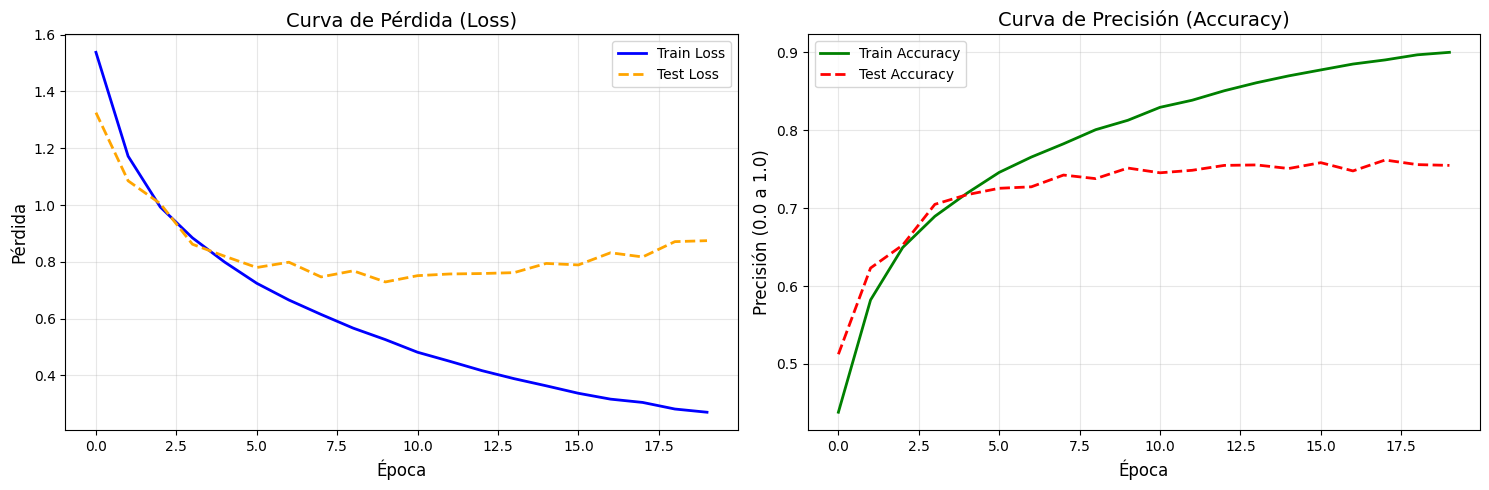

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(cnn_res['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(cnn_res['val_loss'], label='Test Loss', color='orange', linestyle='--', linewidth=2)
ax1.set_title('Curva de Pérdida (Loss)', fontsize=14)
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Pérdida', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax1_acc = cnn_res['train_acc']
ax2_acc = cnn_res['val_acc']

ax2.plot(ax1_acc, label='Train Accuracy', color='green', linewidth=2)
ax2.plot(ax2_acc, label='Test Accuracy', color='red', linestyle='--', linewidth=2)
ax2.set_title('Curva de Precisión (Accuracy)', fontsize=14)
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Precisión (0.0 a 1.0)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Modelo 2 

Modelo mas basico con menos filtros

In [63]:
model_cnn2 = nn.Sequential(
    nn.Conv2d(3, 16, 3, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, 2),              

    nn.Conv2d(16, 32, 3, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, 2),              

    nn.Flatten(),
    nn.Linear(32 * 8 * 8, 128),      
    nn.ReLU(),
    nn.Linear(128, 10) 
).to(device)

model_cnn2 = model_cnn2.to(device)

In [64]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn2.parameters())

cnn_res2 = train(model_cnn2, train_loader, test_loader, loss_function, optimizer, epochs)

cnn_test_loss, cnn_test_acc = test(model_cnn2, test_loader, loss_function)

Training: 100%|██████████| 20/20 [02:37<00:00,  7.87s/epoch, train_acc=0.8674, train_loss=0.3722, val_acc=0.6787, val_loss=1.1810]


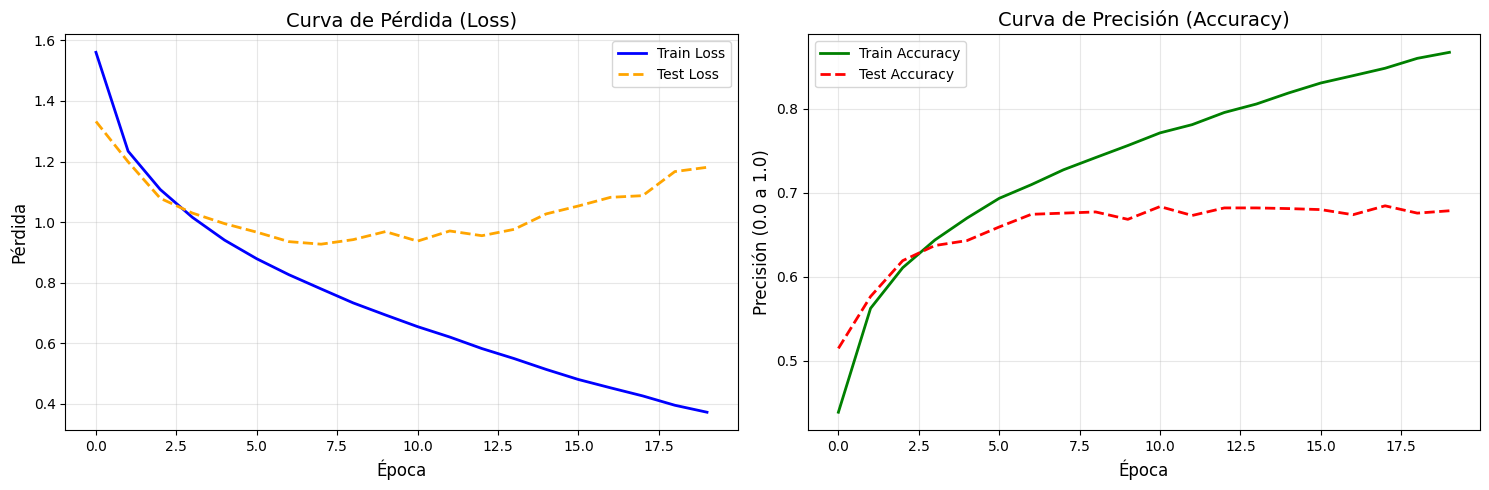

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(cnn_res2['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(cnn_res2['val_loss'], label='Test Loss', color='orange', linestyle='--', linewidth=2)
ax1.set_title('Curva de Pérdida (Loss)', fontsize=14)
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Pérdida', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax1_acc = cnn_res2['train_acc']
ax2_acc = cnn_res2['val_acc']

ax2.plot(ax1_acc, label='Train Accuracy', color='green', linewidth=2)
ax2.plot(ax2_acc, label='Test Accuracy', color='red', linestyle='--', linewidth=2)
ax2.set_title('Curva de Precisión (Accuracy)', fontsize=14)
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Precisión (0.0 a 1.0)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Modelo 3

Modelo con mas complejo con mas filtros 

In [66]:
model_cnn3 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, 2),              

    nn.Conv2d(32, 64, 3, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, 2),              

    nn.Conv2d(64, 128, 3, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, 2),              

    nn.Conv2d(128, 256, 3, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, 2),              

    nn.Flatten(),
    nn.Linear(256 * 2 * 2, 512), 
    nn.Dropout(.4),
    nn.ReLU(),
    nn.Linear(512, 10) 
).to(device)

In [67]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn3.parameters())

cnn_res3 = train(model_cnn3, train_loader, test_loader, loss_function, optimizer, epochs)

cnn_test_loss, cnn_test_acc = test(model_cnn3, test_loader, loss_function)

Training: 100%|██████████| 20/20 [04:56<00:00, 14.83s/epoch, train_acc=0.9558, train_loss=0.1260, val_acc=0.7482, val_loss=1.4038]


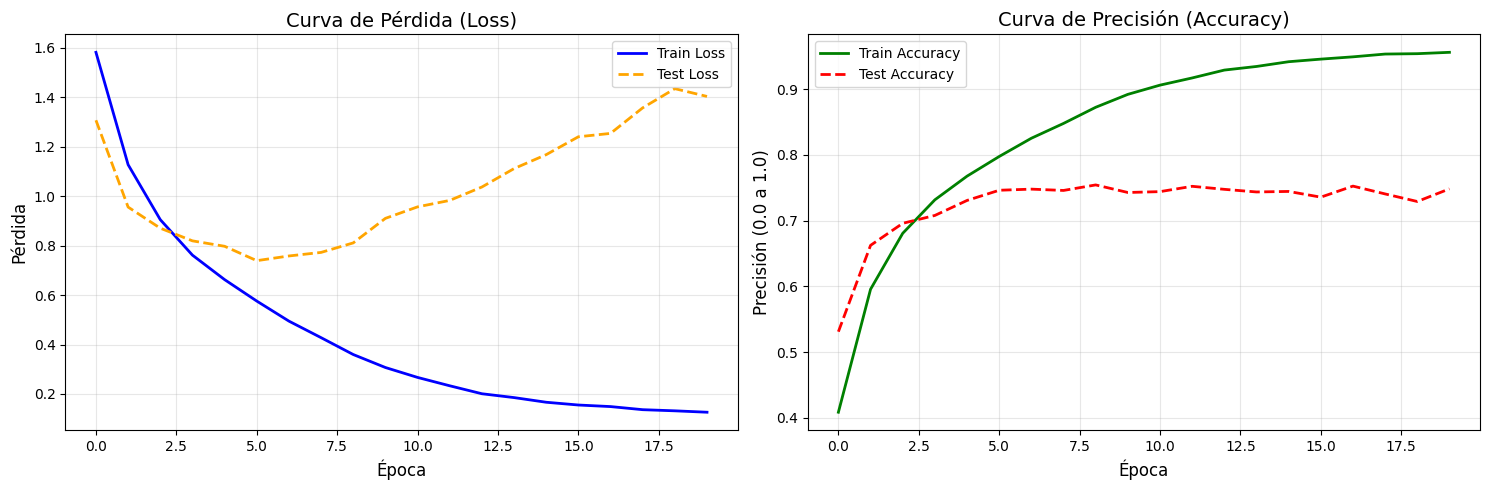

In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(cnn_res3['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(cnn_res3['val_loss'], label='Test Loss', color='orange', linestyle='--', linewidth=2)
ax1.set_title('Curva de Pérdida (Loss)', fontsize=14)
ax1.set_xlabel('Época', fontsize=12)
ax1.set_ylabel('Pérdida', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax1_acc = cnn_res3['train_acc']
ax2_acc = cnn_res3['val_acc']

ax2.plot(ax1_acc, label='Train Accuracy', color='green', linewidth=2)
ax2.plot(ax2_acc, label='Test Accuracy', color='red', linestyle='--', linewidth=2)
ax2.set_title('Curva de Precisión (Accuracy)', fontsize=14)
ax2.set_xlabel('Época', fontsize=12)
ax2.set_ylabel('Precisión (0.0 a 1.0)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusiones 

In [ ]:
#modelo numero 1
final_train_acc = cnn_res['train_acc'][-1]
final_train_loss = cnn_res['train_loss'][-1]
final_test_acc = cnn_res['val_acc'][-1]
final_test_loss = cnn_res['val_loss'][-1]

print(f"--- RESULTADOS FINALES: MODELO 1 ---")
print(f"Precisión Entrenamiento (Train Acc): {final_train_acc * 100:.2f}%")
print(f"Pérdida Entrenamiento (Train Loss):  {final_train_loss:.4f}")
print(f"--------------------------------------")
print(f"Precisión Prueba (Test Acc):        {final_test_acc * 100:.2f}%")
print(f"Pérdida Prueba (Test Loss):         {final_test_loss:.4f}")
print(f"--------------------------------------")

#modelo numero 2
final_train_acc = cnn_res2['train_acc'][-1]
final_train_loss = cnn_res2['train_loss'][-1]
final_test_acc = cnn_res2['val_acc'][-1]
final_test_loss = cnn_res2['val_loss'][-1]

print(f"--- RESULTADOS FINALES: MODELO 2 ---")
print(f"Precisión Entrenamiento (Train Acc): {final_train_acc * 100:.2f}%")
print(f"Pérdida Entrenamiento (Train Loss):  {final_train_loss:.4f}")
print(f"--------------------------------------")
print(f"Precisión Prueba (Test Acc):        {final_test_acc * 100:.2f}%")
print(f"Pérdida Prueba (Test Loss):         {final_test_loss:.4f}")
print(f"--------------------------------------")

#modelo numero 3
final_train_acc = cnn_res3['train_acc'][-1]
final_train_loss = cnn_res3['train_loss'][-1]
final_test_acc = cnn_res3['val_acc'][-1]
final_test_loss = cnn_res3['val_loss'][-1]

print(f"--- RESULTADOS FINALES: MODELO 3 ---")
print(f"Precisión Entrenamiento (Train Acc): {final_train_acc * 100:.2f}%")
print(f"Pérdida Entrenamiento (Train Loss):  {final_train_loss:.4f}")
print(f"--------------------------------------")
print(f"Precisión Prueba (Test Acc):        {final_test_acc * 100:.2f}%")
print(f"Pérdida Prueba (Test Loss):         {final_test_loss:.4f}")
print(f"--------------------------------------")



--- RESULTADOS FINALES: MODELO 1 ---
Precisión Entrenamiento (Train Acc): 90.02%
Pérdida Entrenamiento (Train Loss):  0.2706
--------------------------------------
Precisión Prueba (Test Acc):        75.50%
Pérdida Prueba (Test Loss):         0.8745
--------------------------------------
--- RESULTADOS FINALES: MODELO 2 ---
Precisión Entrenamiento (Train Acc): 86.74%
Pérdida Entrenamiento (Train Loss):  0.3722
--------------------------------------
Precisión Prueba (Test Acc):        67.87%
Pérdida Prueba (Test Loss):         1.1810
--------------------------------------
--- RESULTADOS FINALES: MODELO 3 ---
Precisión Entrenamiento (Train Acc): 95.58%
Pérdida Entrenamiento (Train Loss):  0.1260
--------------------------------------
Precisión Prueba (Test Acc):        74.82%
Pérdida Prueba (Test Loss):         1.4038
--------------------------------------


En esta practica se realizo un modelo para el reconociemiento del dataset CIFAR-10 utilizando 3 modelos diferentes, comparando sus resultados y como los diferentes cambios afecta el rendimiento. Para el modelo se utilizo el mismo que se realizo para la practica del ASL, un modelo balanceado, no muy complejo ni muy simple. El segundo fue un modelo mas simple con la intencion de reducir probar si se puede resolver con uno mas menos complejo. Mientras que el tercer fue mas complejo con la intencion de que aprendiaria algo que los otros no puedan. Al final del entrenamiento el primer modelo fue el que obtuvo el rendimiento con relacion al set de testing con un accuracy del 75%. El segundo modelo solo alcanzo un 67% significando que es demasiado simple para resolver este problema. Mientras que el tercer modelo alcanzo un 74% que aunque parezca similar al del primero, tambien obtuvo un loss de 1.4, lo cual significa que el modelo mas complejo resulto en overfitting 